# 1) load data of real subject

In [1]:
from file import Configurator 
config_file_name = "paths_09012026.json"
configurator = Configurator(path_folder="../config/",
                            file_name=config_file_name)
configurator.load()

In [2]:
import h5py
import numpy as np
# Both required for the JupyterPlotManager
from tools import JupyterPlotManager
%matplotlib ipympl

In [3]:
#path = configurator.data["maps"]["whole_subject_1"]["path"]
subject_1 = h5py.File(path, "r")
subject_1_data = np.array(subject_1['csi']['Data'])
subject_1_data = subject_1_data['real'] + 1j*subject_1_data['imag']
print(type(subject_1_data))
print(subject_1_data.shape)
print(subject_1['csi']['RecoPar'].keys())

<class 'numpy.ndarray'>
(840, 35, 64, 64)
<KeysViewHDF5 ['ADCdtPerAngInt_ns', 'AdjBoxSize_Phase', 'AdjBoxSize_Read', 'AdjBoxSize_Slice', 'AngIntsPerPartEnc', 'AssumedSequence', 'AsymmetricEcho', 'AverageDataDuringReshape_flag', 'DataSize', 'Dwelltimes', 'FirstCirclekSpacePoint', 'FoV_Partition', 'FoV_Phase', 'FoV_Read', 'Full_ElliptWeighted_Or_Weighted_Acq', 'GyroMagnRatioOverTwoPi', 'Hamming_flag', 'HighGain_flag', 'InPlaneRotation', 'InPlaneRotation_VOI', 'InterleavedSliceAcquisition', 'LarmorFreq', 'Nucleus', 'PhasePartialFourier', 'PosVOI_Cor', 'PosVOI_Sag', 'PosVOI_Tra', 'Pos_Cor', 'Pos_Sag', 'Pos_Tra', 'ReadoutOSFactor', 'RefAmplitude', 'RemoveOversampling', 'RewPts', 'SaveUncombined_flag', 'SliceGap', 'SliceNormalVector_VOI_x', 'SliceNormalVector_VOI_y', 'SliceNormalVector_VOI_z', 'SliceNormalVector_x', 'SliceNormalVector_y', 'SliceNormalVector_z', 'SlicePartialFourier', 'SliceThickness', 'SpatialSpectralEncoding_flag', 'SpatialSpectralEncoding_type', 'TEs', 'TIs', 'TR', 'ThreeD

In [4]:

# get paramaters
# vectorSize
# dwellTime

# Load simulated data (better to load created .mat file)

In [5]:
import dask.array as da
import os
import file
from scipy.io import loadmat

config_file_name = "paths_09012026.json"
configurator = file.Configurator(path_folder="../config/",
                                 file_name=config_file_name)
configurator.load()

simulation = h5py.File(os.path.join(configurator.data["checkpoints"], "mat","checkpoint_out_test_12032026_with_header_h5_2.mat"), "r")
simulation_data = np.array(simulation['csi']['Data'])

simulation_data = simulation_data['real'] + 1j*simulation_data['imag']
print(type(simulation_data))
print(simulation_data.shape)
print(simulation['csi']['RecoPar'].keys())

<class 'numpy.ndarray'>
(64, 64, 40, 1536, 1, 1)
<KeysViewHDF5 ['DataSize', 'Dwelltimes', 'FoV_Partion', 'FoV_Phase', 'FoV_Read', 'LarmorFreq', 'SliceNormalVector_VOI_x', 'SliceNormalVector_VOI_y', 'SliceNormalVector_VOI_z', 'SliceNormalVector_x', 'SliceNormalVector_y', 'SliceNormalVector_z', 'TEs', 'TR', 'vecSize']>


In [6]:
print(simulation['csi']['RecoPar'].keys())

<KeysViewHDF5 ['DataSize', 'Dwelltimes', 'FoV_Partion', 'FoV_Phase', 'FoV_Read', 'LarmorFreq', 'SliceNormalVector_VOI_x', 'SliceNormalVector_VOI_y', 'SliceNormalVector_VOI_z', 'SliceNormalVector_x', 'SliceNormalVector_y', 'SliceNormalVector_z', 'TEs', 'TR', 'vecSize']>


# Compare Parameters Simulation and Real Data

In [7]:
parameters = [
    "DataSize",
    "Dwelltimes",
    "FoV_Partion",
    "FoV_Phase",
    "FoV_Read",
    "LarmorFreq",
    "SliceNormalVector_VOI_x",
    "SliceNormalVector_VOI_y",
    "SliceNormalVector_VOI_z",
    "SliceNormalVector_x",
    "SliceNormalVector_y",
    "SliceNormalVector_z",
    "TR",
    "TEs",
    "vecSize",
]

#for i, p in enumerate(parameters):
#    print(f"{1}: {p}: sim:{simulation['csi']['RecoPar'][p]} | real:{subject_1['csi']['RecoPar'][p]}")

print(np.array(simulation['csi']['RecoPar']))
print(np.array(subject_1['csi']['RecoPar']))

['DataSize' 'Dwelltimes' 'FoV_Partion' 'FoV_Phase' 'FoV_Read' 'LarmorFreq'
 'SliceNormalVector_VOI_x' 'SliceNormalVector_VOI_y'
 'SliceNormalVector_VOI_z' 'SliceNormalVector_x' 'SliceNormalVector_y'
 'SliceNormalVector_z' 'TEs' 'TR' 'vecSize']
['ADCdtPerAngInt_ns' 'AdjBoxSize_Phase' 'AdjBoxSize_Read'
 'AdjBoxSize_Slice' 'AngIntsPerPartEnc' 'AssumedSequence' 'AsymmetricEcho'
 'AverageDataDuringReshape_flag' 'DataSize' 'Dwelltimes'
 'FirstCirclekSpacePoint' 'FoV_Partition' 'FoV_Phase' 'FoV_Read'
 'Full_ElliptWeighted_Or_Weighted_Acq' 'GyroMagnRatioOverTwoPi'
 'Hamming_flag' 'HighGain_flag' 'InPlaneRotation' 'InPlaneRotation_VOI'
 'InterleavedSliceAcquisition' 'LarmorFreq' 'Nucleus'
 'PhasePartialFourier' 'PosVOI_Cor' 'PosVOI_Sag' 'PosVOI_Tra' 'Pos_Cor'
 'Pos_Sag' 'Pos_Tra' 'ReadoutOSFactor' 'RefAmplitude' 'RemoveOversampling'
 'RewPts' 'SaveUncombined_flag' 'SliceGap' 'SliceNormalVector_VOI_x'
 'SliceNormalVector_VOI_y' 'SliceNormalVector_VOI_z' 'SliceNormalVector_x'
 'SliceNormalVector_

In [8]:
#from spectral_spatial_simulation import FID

In [9]:
#FID(signal=np.array(subject_1_data[:, 35,35,20]), time=loaded_fid.time, name=f"FID at 35,35,20")

In [10]:
import numpy as np
print(subject_1_data.shape)
print(np.transpose(np.squeeze(simulation_data), (3,2,1,0)).shape)
#simulated_data_prepared = np.permute(np.squeeze(simulation_data))
#simulated_data_prepared.shape

simulation_data_1 = np.transpose(np.squeeze(simulation_data), (3,2,1,0))
real_data_1 = np.flip(subject_1_data, 2)

(840, 35, 64, 64)
(1536, 40, 64, 64)


# Plot real and simulated data

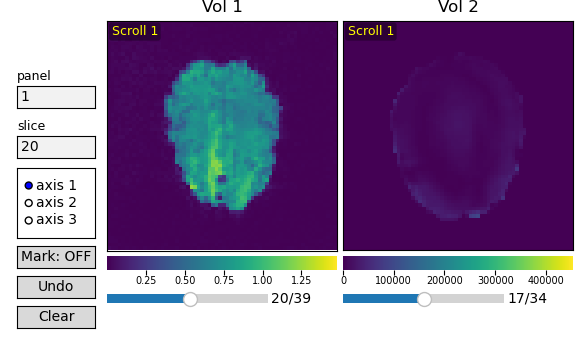

(<Figure size 586x337 with 12 Axes>,
 array([[<Axes: title={'center': 'Vol 1'}>,
         <Axes: title={'center': 'Vol 2'}>]], dtype=object),
 {'layout_all': <function tools.JupyterPlotManager.volume_grid_viewer.<locals>.layout_all()>,
  'selected_panel': [0],
  'axis_per_panel': [0, 0],
  'sliders': {0: <matplotlib.widgets.Slider at 0x7f4cad6f2890>,
   1: <matplotlib.widgets.Slider at 0x7f4cad58e950>},
  'images': {0: <matplotlib.image.AxesImage at 0x7f4cad669c60>,
   1: <matplotlib.image.AxesImage at 0x7f4cad72e920>},
  'markers': [],
  'marking_enabled': [False],
  'click_cid': 41,
  'key_cid': 42,
  'marker_counts': {},
  'slider_tick_lines': {}})

In [11]:
JupyterPlotManager.volume_grid_viewer(vols=[np.abs(simulation_data_1[0, :,:,:]), np.abs(real_data_1[0, :,:,:])], rows=1, cols=2, cmap="viridis")

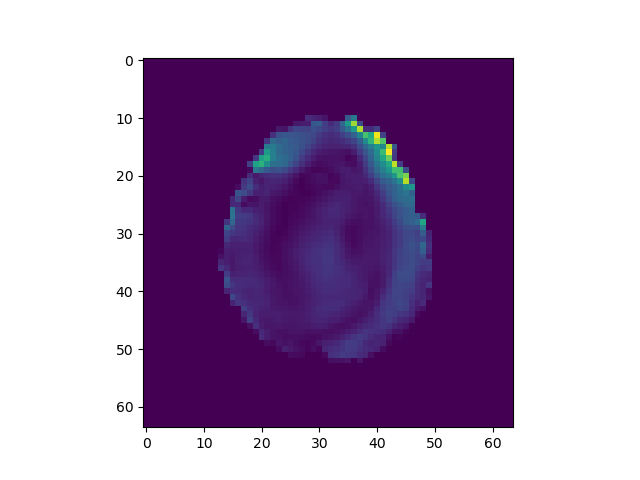

In [12]:
import matplotlib.pyplot as plt
real_data_1_flipped = np.flip(real_data_1, 2)

plt.figure()
plt.imshow(np.abs(real_data_1_flipped[0, 20,:,:]))
plt.show()

In [13]:
# Orientation different
# Matrix size different
# FOV different?
# What is voxel size?

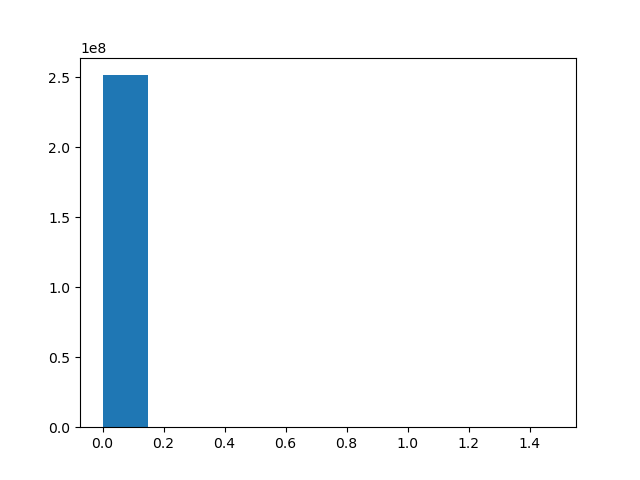

In [14]:
#simulated: 17,27,41
#real: 15,25,41
np.max(simulation_data_1)
np.std(simulation_data_1)
import matplotlib.pyplot as plt

plt.figure()
plt.hist(np.abs(simulation_data_1.flatten()))
plt.show()

/opt/conda/envs/MRSI_simulation/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/conda/envs/MRSI_simulation/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


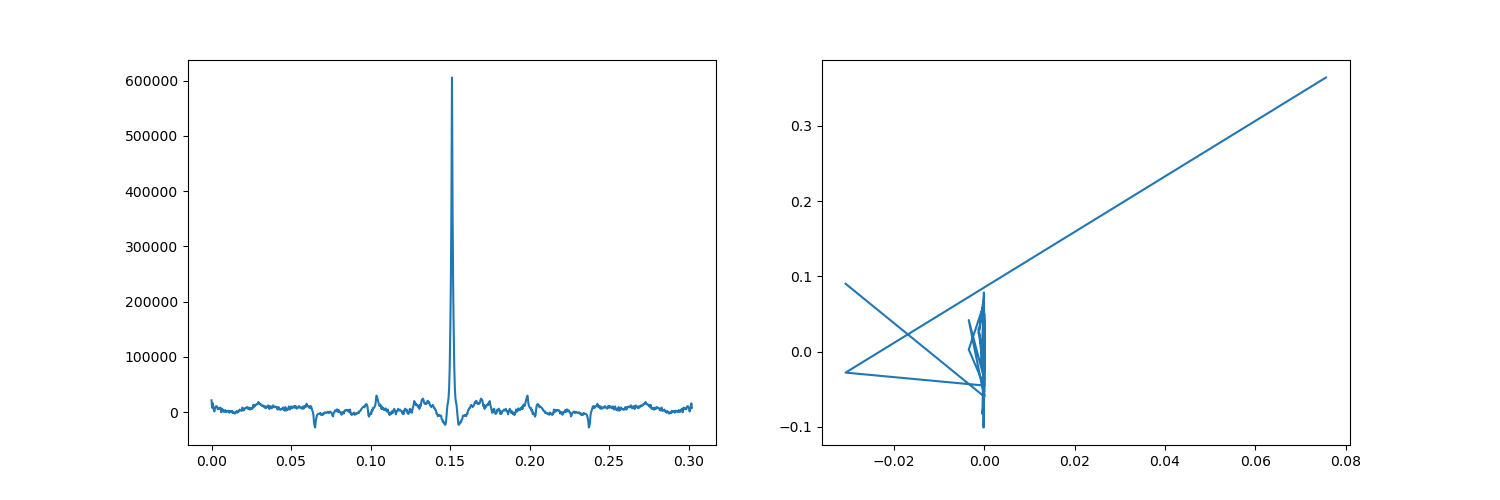

In [15]:
#simulated: 17,27,41
#real: 15,25,41


step_real = np.array(subject_1['csi']['RecoPar']['Dwelltimes']).squeeze() / (10**9)
real_data_1_flipped_time_vector = np.array([x*step_real for x in range(len(real_data_1_flipped))])

step_sim = np.array(simulation['csi']['RecoPar']['Dwelltimes']).squeeze() / (10**9)
sim_data_1_flipped_time_vector = np.array([x*step_real for x in range(len(simulation_data_1))])

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(real_data_1_flipped_time_vector, np.fft.fftshift(np.fft.fftn(np.abs(real_data_1_flipped)[:,15,25,41])))
plt.subplot(1,2,2)
plt.plot(  np.fft.irfft(sim_data_1_flipped_time_vector, n=len(real_data_1_flipped)), np.fft.irfft(np.fft.fftshift(np.fft.fftn(np.abs(simulation_data_1)[:,17,27,41])),  n=len(real_data_1_flipped))   )
plt.show()

In [16]:
from spectral_spatial_simulation import FID

simulation_data_1[:, 15,25,41].shape

(1536,)

[  8  ][ warning ] >> No reference frequency is specified. Choosing: 297223042 Hz.                                         
[  9  ][ warning ] >> No ppm center is specified. Choosing: 4.7 ppm.                                                       


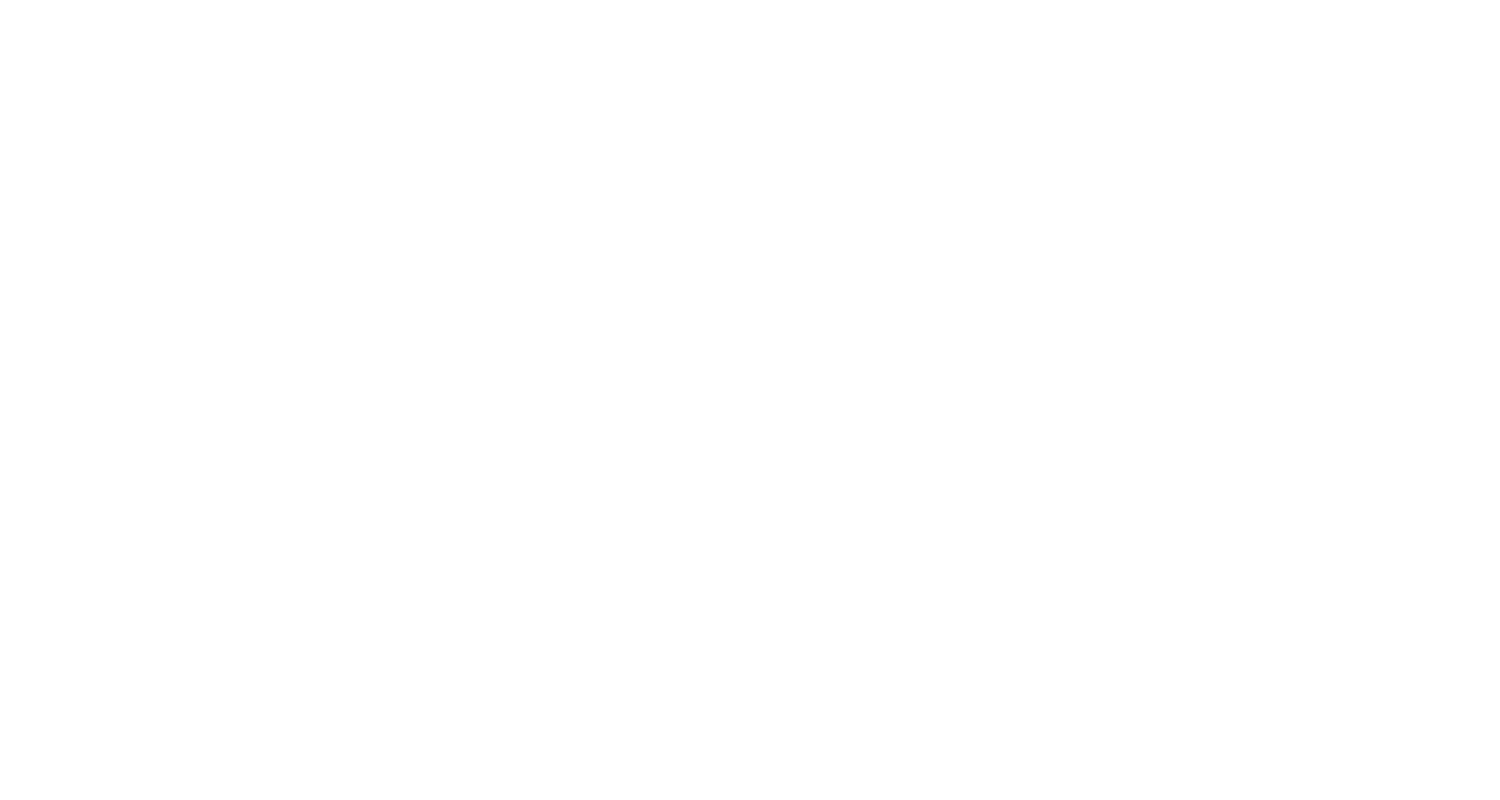

[ 10  ][ warning ] >> No reference frequency is specified. Choosing: 297223042 Hz.                                         
[ 11  ][ warning ] >> No ppm center is specified. Choosing: 4.7 ppm.                                                       


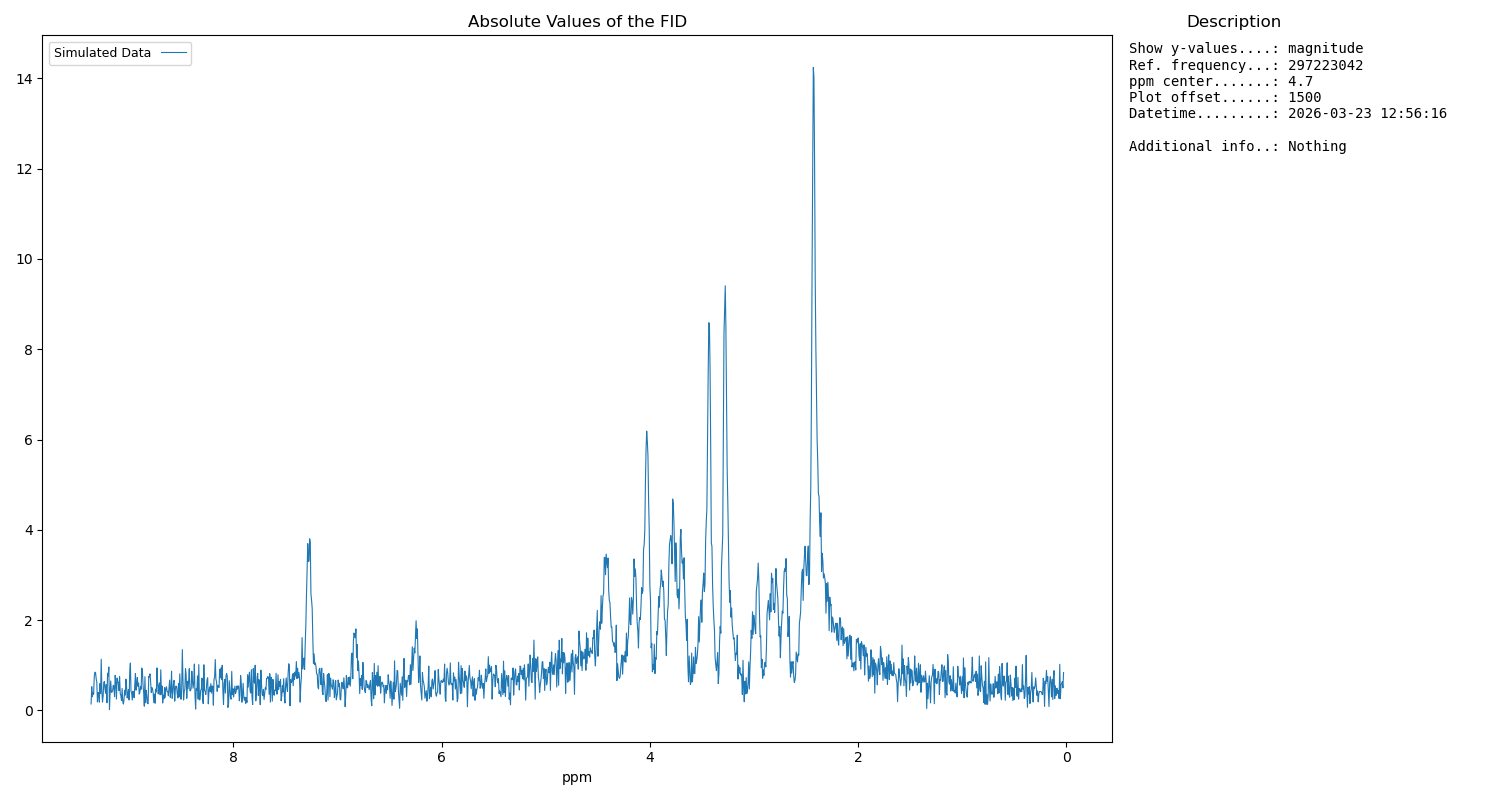

In [28]:
fid_one_signal = FID(signal=np.array(real_data_1_flipped[:, 17,27,41]), time=real_data_1_flipped_time_vector, name=f"real: FID at 35,35,20")
fid_one_signal.name = ["Real Data"]

fid_one_signal.plot()

fid_one_signal2 = FID(signal=simulation_data_1[:, 15,25,41], time=sim_data_1_flipped_time_vector, name=f"sim: FID at 15,25,41")
fid_one_signal2.name = ["Simulated Data"]

fid_one_signal2.plot()
#fid_one_signal2.interpolate(timepoints=len(real_data_1_flipped))

#fid_one_signal.plot()

#fid_real = FID()
#fid_real.signal = []

In [26]:
print(fid_one_signal.time.shape, fid_one_signal.signal.shape)
print(fid_one_signal2.time.shape, fid_one_signal2.signal.shape)

(840,) (840,)
(840,) (840,)


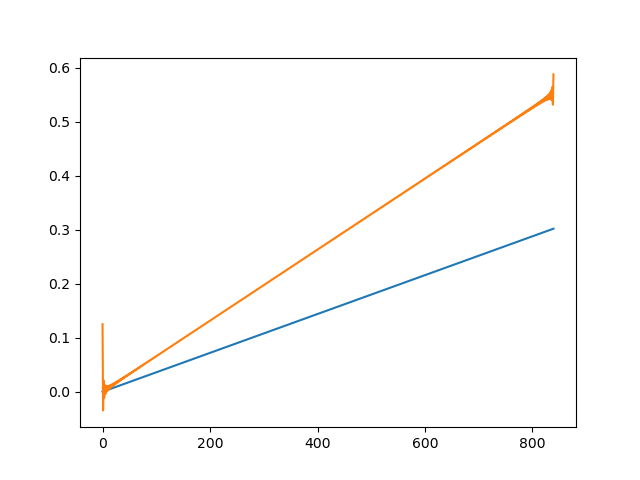

In [27]:
plt.figure()
plt.plot(fid_one_signal.time)
plt.plot(fid_one_signal2.time)
plt.show()

In [18]:
fid_one_signal = fid_one_signal + fid_one_signal2

[  4  ][  error  ] ---v  (automatic line breaks) 
                      Not possible to sum the two FID since the time vectors are different! Vector 1: (840,), Vector 2;
                      (840,)


In [46]:
start = 0
step = 3.0E-4
end = 0.46080002

In [48]:
np.arange(start, end, step).shape

(1537,)

In [60]:
# with length of FID points I will also get the same results?

np.array([x*step for x in range(len(simulation_data_1))]).shape

(1536,)

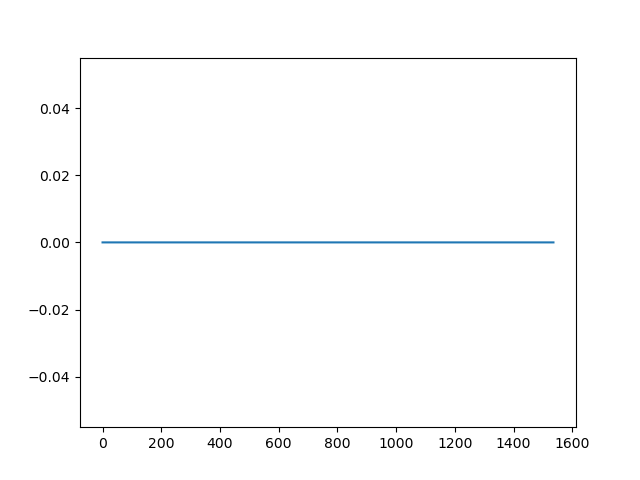

In [57]:
plt.figure()
plt.plot(np.arange(start, end, step) - np.array([x*step for x in range(1537)]))
plt.show()